# K-Nearest Neighbor Classifiers for the MNIST Dataset
## k Selected via Cross-Validation

This notebook mirrors the Penguins KNN workflow on the MNIST handwritten-digit dataset (70 000 images, 28×28 pixels = 784 features per sample).

Two classifiers are trained, with k chosen independently by cross-validation for each:

| Classifier | Target | Classes |
|---|---|---|
| **1 — Digit** | Digit identity | 10 classes (0–9) |
| **2 — Parity** | Even vs. Odd digit | Binary (0 = Even, 1 = Odd) |

### Handling MNIST's Scale
Raw MNIST has 784 features and 70 000 samples. Running KNN directly would be impractical:
- **Dimensionality reduction via PCA** compresses 784 pixel features to a much smaller set of principal components, dramatically reducing the per-query distance computation time while retaining most of the variance.
- **k sweep on a stratified subsample** (10 000 training images) keeps cross-validation fast. The final model is then refit on the full 60 000-image training set for maximum accuracy.

## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE  = 42
N_PCA_COMPONENTS = 50   # retains ~85% of variance; keeps KNN fast
CV_FOLDS      = 5
K_MAX         = 20       # sweep k = 1 .. 20
CV_SUBSAMPLE  = 10_000   # samples used for the k-sweep CV (speed)

np.random.seed(RANDOM_STATE)
print("All libraries imported.")

All libraries imported.


## 2. Load MNIST and Explore the Data

In [2]:
# fetch_openml caches the download locally after the first call (~55 MB)
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")

X_raw = mnist.data.astype(np.float32)          # shape (70000, 784), pixel values 0–255
y_digit = mnist.target.astype(np.int32)        # shape (70000,), labels 0–9

print(f"Dataset shape : {X_raw.shape}")
print(f"Label range   : {y_digit.min()} – {y_digit.max()}")
print(f"Class counts  :\n{pd.Series(y_digit).value_counts().sort_index().to_string()}")

Dataset shape : (70000, 784)
Label range   : 0 – 9
Class counts  :
0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958


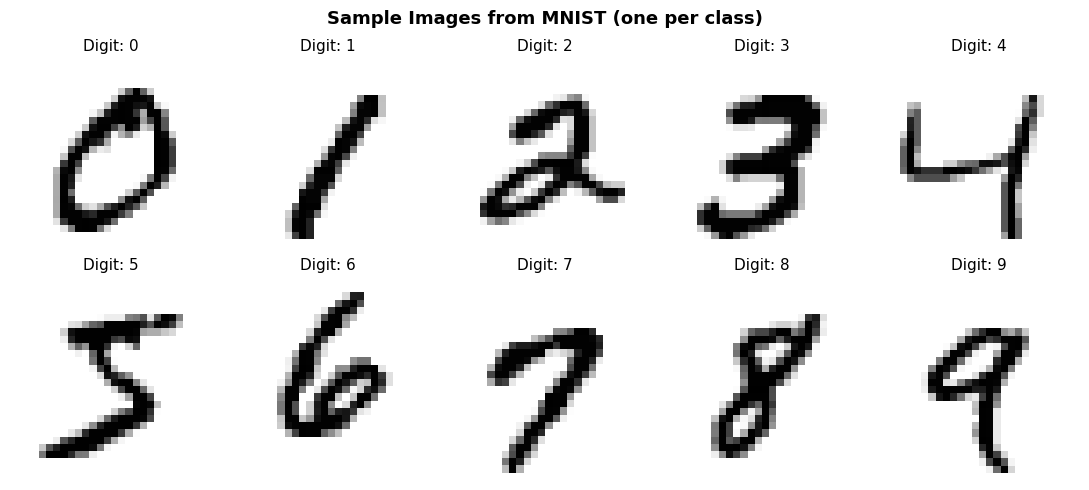

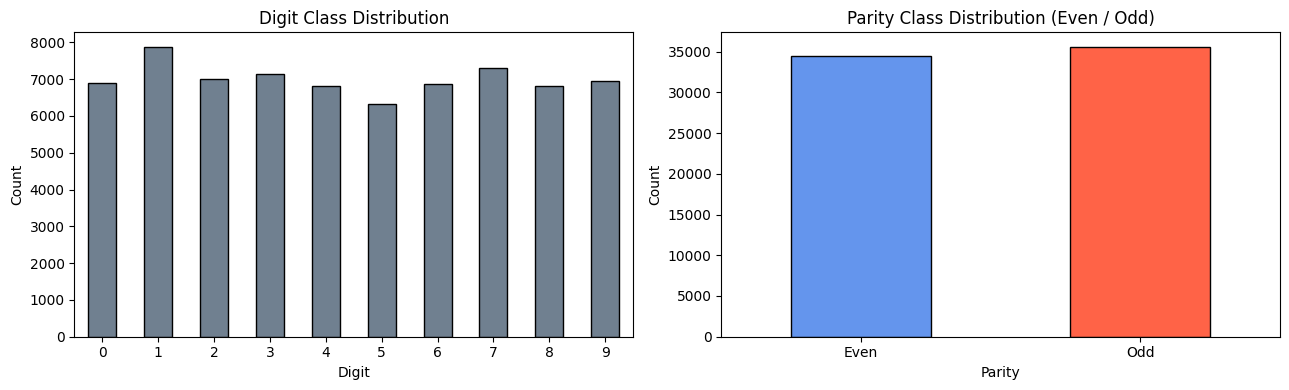

In [3]:
# Display one example per digit class
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for digit, ax in zip(range(10), axes.ravel()):
    idx = np.where(y_digit == digit)[0][0]
    ax.imshow(X_raw[idx].reshape(28, 28), cmap="gray_r", interpolation="nearest")
    ax.set_title(f"Digit: {digit}", fontsize=11)
    ax.axis("off")
fig.suptitle("Sample Images from MNIST (one per class)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Class balance bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts = pd.Series(y_digit).value_counts().sort_index()
counts.plot(kind="bar", ax=axes[0], color="slategray", edgecolor="black")
axes[0].set_title("Digit Class Distribution", fontsize=12)
axes[0].set_xlabel("Digit"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

y_parity = (y_digit % 2).astype(np.int32)
pd.Series(y_parity).value_counts().sort_index().rename({0: "Even", 1: "Odd"}).plot(
    kind="bar", ax=axes[1], color=["cornflowerblue", "tomato"], edgecolor="black"
)
axes[1].set_title("Parity Class Distribution (Even / Odd)", fontsize=12)
axes[1].set_xlabel("Parity"); axes[1].set_ylabel("Count")
axes[1].set_xticklabels(["Even", "Odd"], rotation=0)

plt.tight_layout()
plt.show()

## 3. Preprocessing — Normalisation, Train/Test Split, and PCA

MNIST's canonical split is the first 60 000 rows for training and the last 10 000 for testing.
We honour that split, then apply `StandardScaler` followed by `PCA` inside a pipeline.
The scaler and PCA are **fit only on training data** to prevent information leakage.

Training set : (60000, 784)  |  Test set : (10000, 784)

PCA: 50 components retain 55.1% of variance (reduced from 784 → 50 dims)


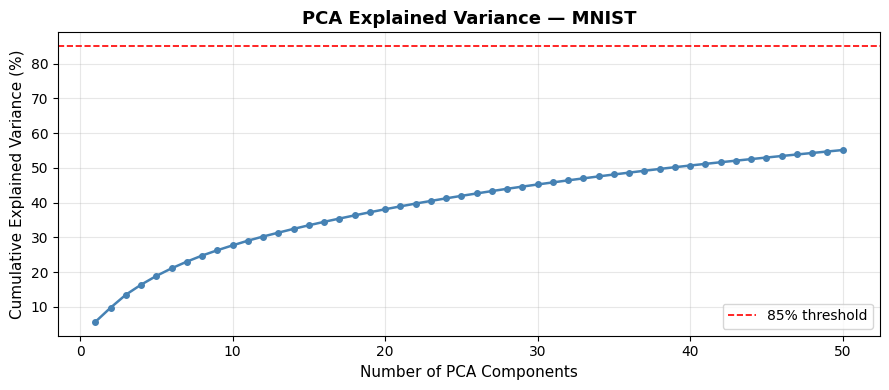

In [4]:
# Use MNIST's canonical train/test split
X_train_full, X_test = X_raw[:60_000], X_raw[60_000:]
y_digit_train_full,  y_digit_test  = y_digit[:60_000],  y_digit[60_000:]
y_parity_train_full, y_parity_test = y_parity[:60_000], y_parity[60_000:]

print(f"Training set : {X_train_full.shape}  |  Test set : {X_test.shape}")

# ---------------------------------------------------------------
# Fit a shared scaler + PCA on training data only.
# The same transform is applied to the test set.
# ---------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled  = scaler.transform(X_test)

pca = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

explained = pca.explained_variance_ratio_.cumsum()[-1]
print(f"\nPCA: {N_PCA_COMPONENTS} components retain {explained*100:.1f}% of variance "
      f"(reduced from 784 → {N_PCA_COMPONENTS} dims)")

# Visualise explained variance
fig, ax = plt.subplots(figsize=(9, 4))
cumvar = pca.explained_variance_ratio_.cumsum()
ax.plot(range(1, N_PCA_COMPONENTS + 1), cumvar * 100, marker="o", markersize=4,
        color="steelblue", linewidth=1.8)
ax.axhline(85, color="red", linestyle="--", linewidth=1.2, label="85% threshold")
ax.set_xlabel("Number of PCA Components", fontsize=11)
ax.set_ylabel("Cumulative Explained Variance (%)", fontsize=11)
ax.set_title("PCA Explained Variance — MNIST", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# Stratified subsample from the PCA-transformed training set for the k-sweep CV
# (fitting KNN on 60 000 samples × 20 k values × 5 folds would take hours)
idx_sub = np.random.choice(len(X_train_pca), size=CV_SUBSAMPLE, replace=False)
X_cv = X_train_pca[idx_sub]
y_digit_cv  = y_digit_train_full[idx_sub]
y_parity_cv = y_parity_train_full[idx_sub]

print(f"CV subsample : {X_cv.shape}  (stratified draw from 60 000 training images)")

CV subsample : (10000, 50)  (stratified draw from 60 000 training images)


## 4. Helper: k Selection via Cross-Validation

In [6]:
def select_k(X_cv, y_cv, label: str, color: str,
             k_max: int = K_MAX, cv_folds: int = CV_FOLDS):
    """
    Sweep k=1..k_max on pre-transformed CV data (no scaler/PCA inside pipeline
    since data is already transformed).  Returns best_k, cv_means, cv_stds.
    """
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    k_range  = np.arange(1, k_max + 1)
    cv_means = np.zeros(k_max)
    cv_stds  = np.zeros(k_max)

    print(f"Sweeping k = 1 … {k_max} for {label} classifier ", end="", flush=True)
    for i, k in enumerate(k_range):
        knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean", n_jobs=-1)
        scores = cross_val_score(knn, X_cv, y_cv, cv=skf, scoring="accuracy")
        cv_means[i] = scores.mean()
        cv_stds[i]  = scores.std()
        print(".", end="", flush=True)
    print(" done.")

    best_idx = int(np.argmax(cv_means))
    best_k   = int(k_range[best_idx])

    # CV accuracy vs k plot
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(k_range, cv_means, marker="o", color=color, linewidth=1.8, label="CV mean accuracy")
    ax.fill_between(k_range, cv_means - cv_stds, cv_means + cv_stds,
                    alpha=0.2, color=color, label="±1 std")
    ax.axvline(best_k, color="red", linestyle="--", linewidth=1.5,
               label=f"Best k = {best_k}  (acc = {cv_means[best_idx]:.4f})")
    ax.set_xlabel("k (number of neighbors)", fontsize=12)
    ax.set_ylabel(f"{cv_folds}-Fold CV Accuracy", fontsize=12)
    ax.set_title(f"k Selection via Cross-Validation — {label} Classifier", fontsize=13, fontweight="bold")
    ax.set_xticks(k_range)
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"[{label}] Best k = {best_k}  |  CV Accuracy = {cv_means[best_idx]:.4f} ± {cv_stds[best_idx]:.4f}")
    return best_k, cv_means, cv_stds

print("Helper defined.")

Helper defined.


## 5. Classifier 1 — Digit Recognition (0–9)

### 5.1 k Selection via Cross-Validation — Digit

Sweeping k = 1 … 20 for Digit classifier .................... done.


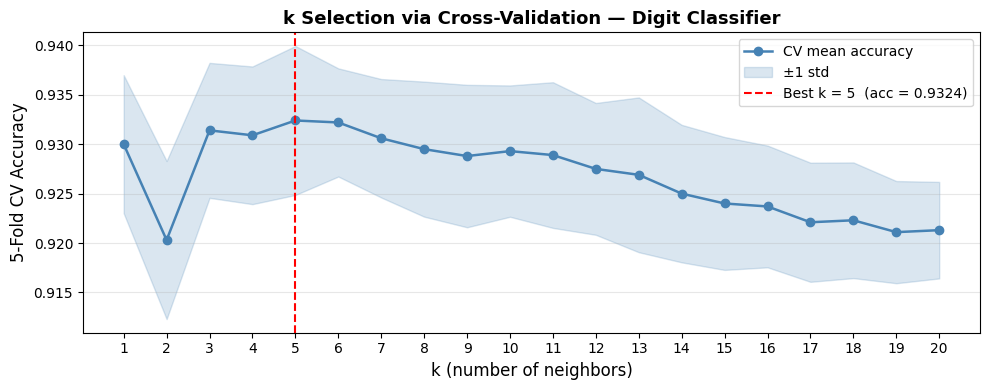

[Digit] Best k = 5  |  CV Accuracy = 0.9324 ± 0.0075


In [7]:
best_k_digit, cv_means_digit, cv_stds_digit = select_k(
    X_cv, y_digit_cv, label="Digit", color="steelblue"
)

### 5.2 Train Final Digit Classifier on Full Training Set

In [8]:
print(f"Training final digit KNN (k={best_k_digit}) on all 60 000 PCA-transformed samples …")
knn_digit = KNeighborsClassifier(n_neighbors=best_k_digit, metric="euclidean", n_jobs=-1)
knn_digit.fit(X_train_pca, y_digit_train_full)
print("Done.")

Training final digit KNN (k=5) on all 60 000 PCA-transformed samples …
Done.


### 5.3 PCA Feature Space Visualization — Digit

Since we cannot draw a 50-D decision boundary, we visualise the first two principal components coloured by digit class.

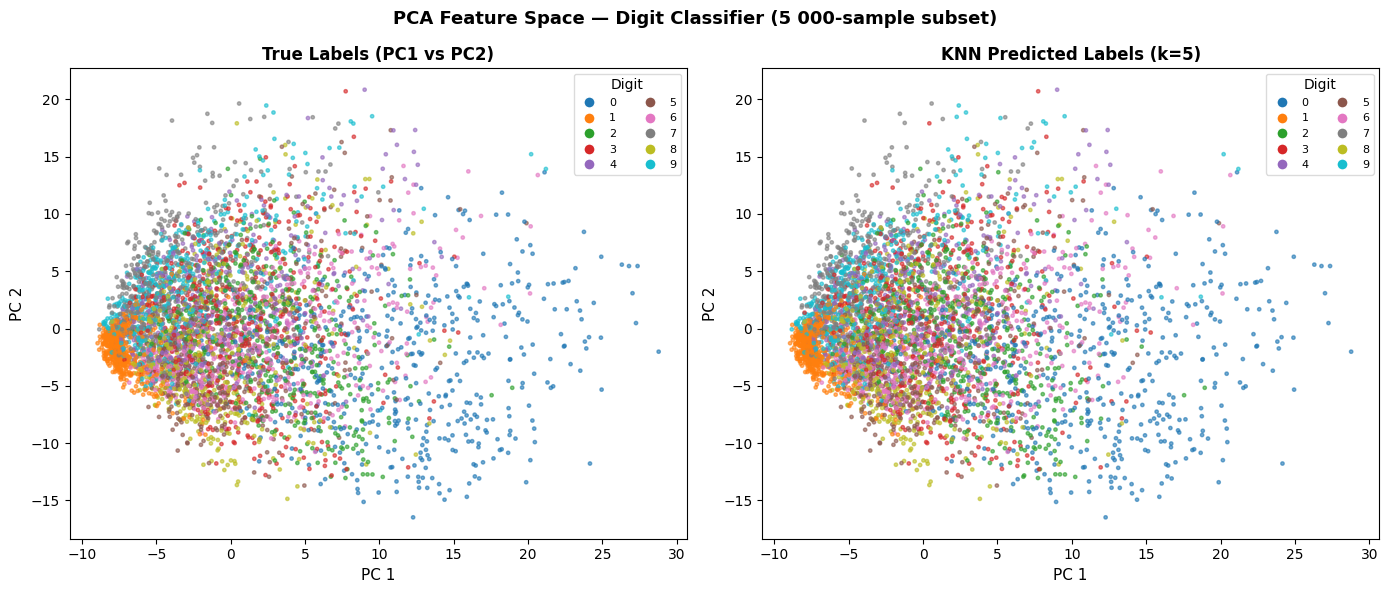

In [9]:
VIZ_N = 5_000   # subsample for scatter (all 60 k points overplot badly)
rng = np.random.default_rng(RANDOM_STATE)
viz_idx = rng.choice(len(X_train_pca), size=VIZ_N, replace=False)

X_viz   = X_train_pca[viz_idx]
y_viz   = y_digit_train_full[viz_idx]
y_pred_viz = knn_digit.predict(X_viz)

cmap10 = plt.get_cmap("tab10")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, labels, title in zip(
    axes,
    [y_viz, y_pred_viz],
    ["True Labels (PC1 vs PC2)", f"KNN Predicted Labels (k={best_k_digit})"]
):
    sc = ax.scatter(X_viz[:, 0], X_viz[:, 1],
                    c=labels, cmap="tab10", s=6, alpha=0.6,
                    vmin=-0.5, vmax=9.5)
    ax.set_xlabel("PC 1", fontsize=11)
    ax.set_ylabel("PC 2", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    handles = [plt.Line2D([0], [0], marker="o", color="w",
                           markerfacecolor=cmap10(d / 9), markersize=8, label=str(d))
               for d in range(10)]
    ax.legend(handles=handles, title="Digit", fontsize=8, loc="upper right",
              ncol=2, framealpha=0.7)

plt.suptitle("PCA Feature Space — Digit Classifier (5 000-sample subset)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 5.4 Performance Evaluation — Digit

Running predictions on 10 000 test images …
  Digit KNN  (k = 5, PCA = 50 components)
  Train Accuracy           : 0.9743
  Test  Accuracy           : 0.9578
  CV Accuracy (subsample)  : 0.9324 ± 0.0075

Classification Report (test set):

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.96      0.96      0.96      1032
           3       0.95      0.95      0.95      1010
           4       0.96      0.96      0.96       982
           5       0.95      0.94      0.95       892
           6       0.96      0.98      0.97       958
           7       0.96      0.93      0.95      1028
           8       0.95      0.94      0.94       974
           9       0.93      0.93      0.93      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



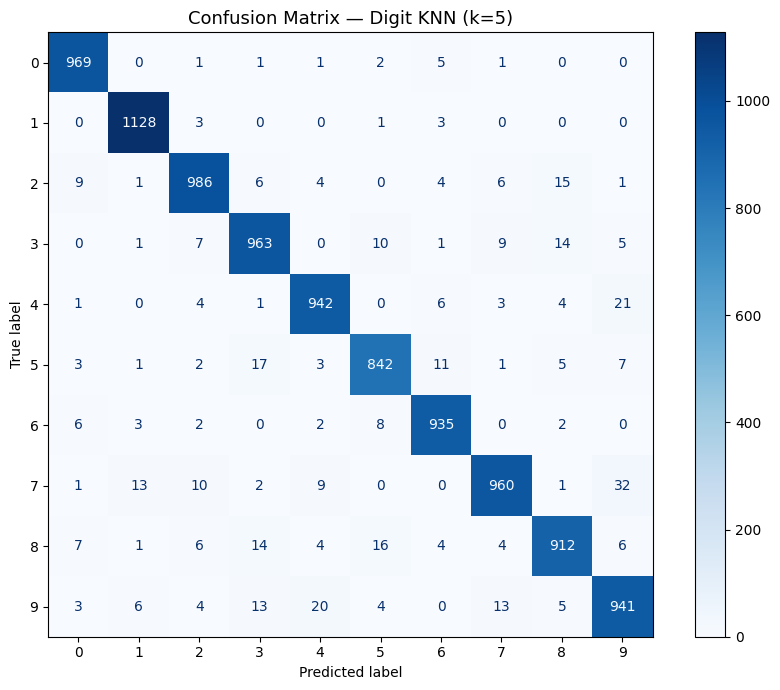

In [10]:
print("Running predictions on 10 000 test images …")
y_pred_digit = knn_digit.predict(X_test_pca)

train_acc_digit = accuracy_score(y_digit_train_full, knn_digit.predict(X_train_pca))
test_acc_digit  = accuracy_score(y_digit_test, y_pred_digit)
best_cv_digit   = cv_means_digit[best_k_digit - 1]
best_cv_std_digit = cv_stds_digit[best_k_digit - 1]

DIGIT_NAMES = [str(d) for d in range(10)]

print("=" * 55)
print(f"  Digit KNN  (k = {best_k_digit}, PCA = {N_PCA_COMPONENTS} components)")
print("=" * 55)
print(f"  Train Accuracy           : {train_acc_digit:.4f}")
print(f"  Test  Accuracy           : {test_acc_digit:.4f}")
print(f"  CV Accuracy (subsample)  : {best_cv_digit:.4f} ± {best_cv_std_digit:.4f}")
print()
print("Classification Report (test set):\n")
print(classification_report(y_digit_test, y_pred_digit, target_names=DIGIT_NAMES))

# Confusion matrix
cm_digit = confusion_matrix(y_digit_test, y_pred_digit)
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm_digit, display_labels=DIGIT_NAMES).plot(
    ax=ax, colorbar=True, cmap="Blues", xticks_rotation="horizontal"
)
ax.set_title(f"Confusion Matrix — Digit KNN (k={best_k_digit})", fontsize=13)
plt.tight_layout()
plt.show()

### 5.5 Misclassified Digit Samples

Visualising the test images that were misclassified reveals which digit pairs the model finds ambiguous.

Misclassified test images: 422 / 10000 (4.22%)


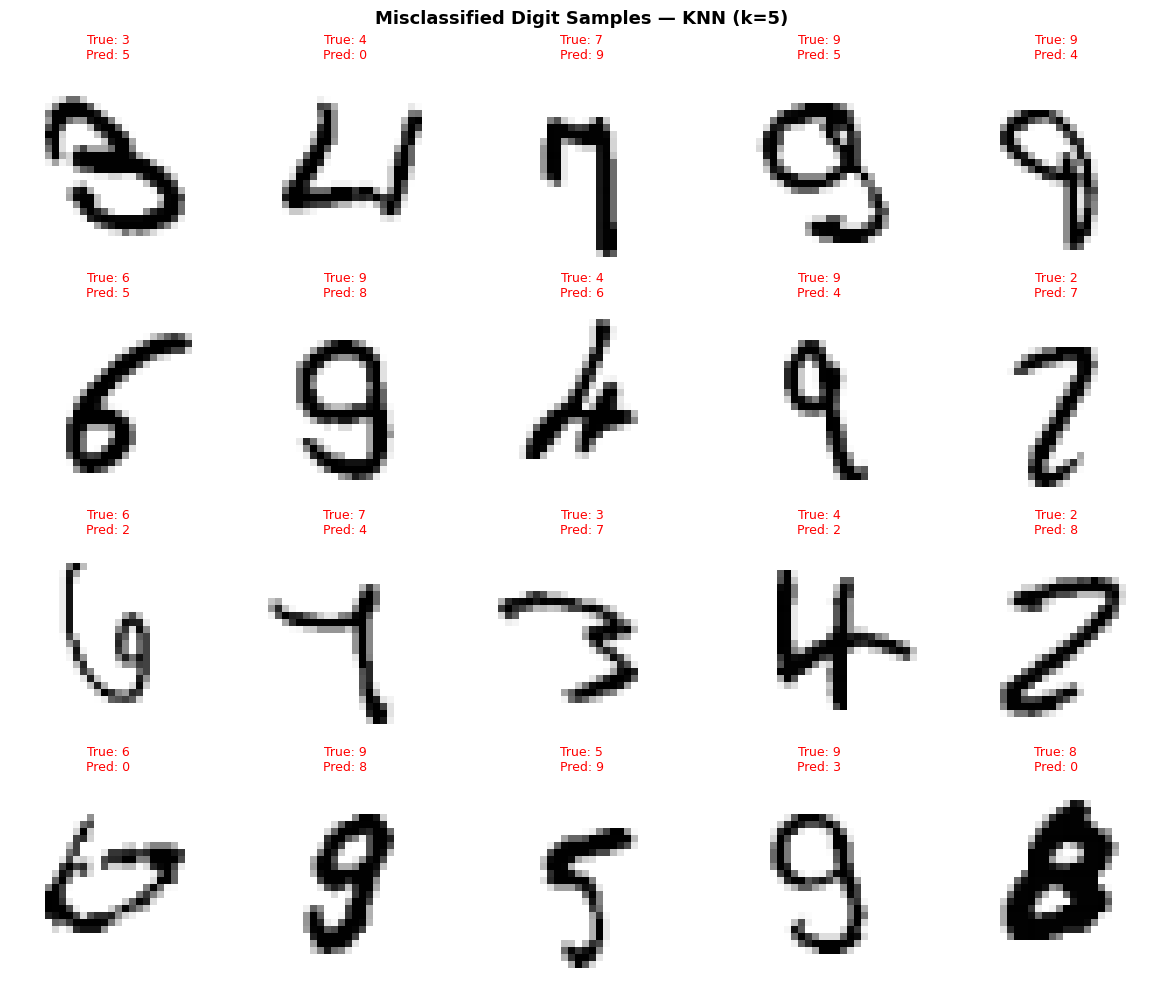

In [11]:
wrong_idx = np.where(y_pred_digit != y_digit_test)[0]
print(f"Misclassified test images: {len(wrong_idx)} / {len(y_digit_test)} "
      f"({len(wrong_idx)/len(y_digit_test)*100:.2f}%)")

# Show up to 20 misclassified examples
show = wrong_idx[:20]
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
for ax, i in zip(axes.ravel(), show):
    ax.imshow(X_test[i].reshape(28, 28), cmap="gray_r", interpolation="nearest")
    ax.set_title(f"True: {y_digit_test[i]}\nPred: {y_pred_digit[i]}",
                 fontsize=9, color="red")
    ax.axis("off")
fig.suptitle(f"Misclassified Digit Samples — KNN (k={best_k_digit})", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Classifier 2 — Parity Recognition (Even / Odd)

### 6.1 k Selection via Cross-Validation — Parity

Sweeping k = 1 … 20 for Parity classifier .................... done.


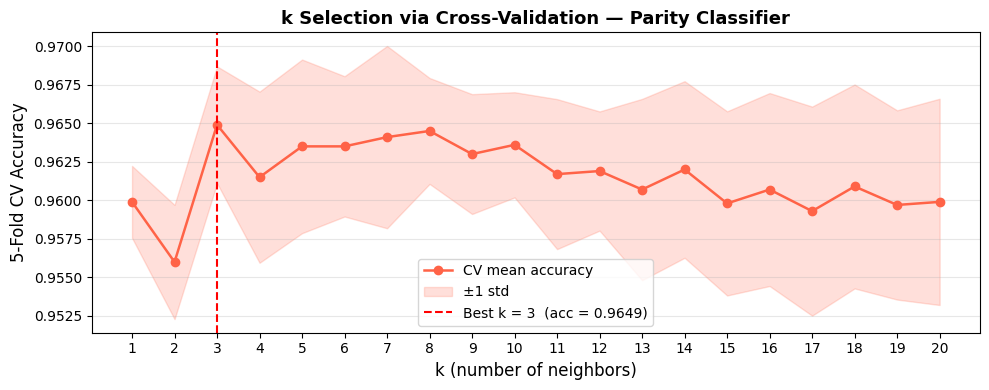

[Parity] Best k = 3  |  CV Accuracy = 0.9649 ± 0.0038


In [12]:
best_k_parity, cv_means_parity, cv_stds_parity = select_k(
    X_cv, y_parity_cv, label="Parity", color="tomato"
)

### 6.2 Train Final Parity Classifier on Full Training Set

In [13]:
print(f"Training final parity KNN (k={best_k_parity}) on all 60 000 PCA-transformed samples …")
knn_parity = KNeighborsClassifier(n_neighbors=best_k_parity, metric="euclidean", n_jobs=-1)
knn_parity.fit(X_train_pca, y_parity_train_full)
print("Done.")

Training final parity KNN (k=3) on all 60 000 PCA-transformed samples …
Done.


### 6.3 PCA Feature Space Visualization — Parity

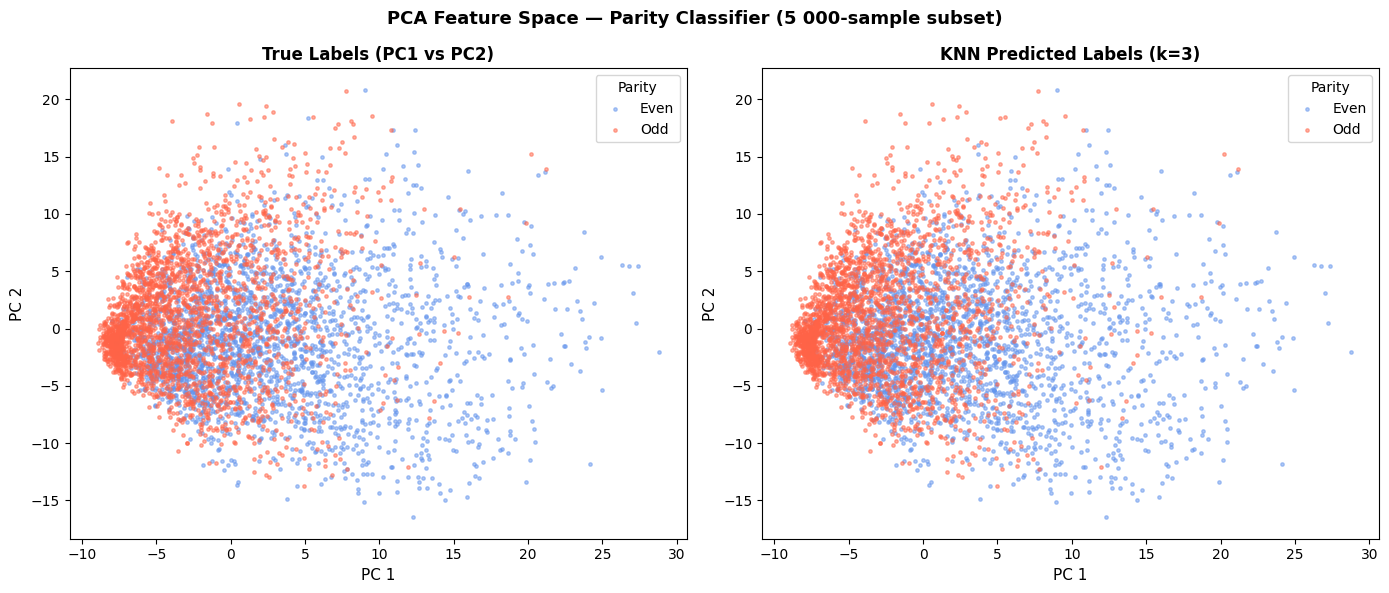

In [14]:
y_viz_parity      = y_parity_train_full[viz_idx]
y_pred_viz_parity = knn_parity.predict(X_viz)

PARITY_NAMES = ["Even", "Odd"]
parity_colors = ["cornflowerblue", "tomato"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, labels, title in zip(
    axes,
    [y_viz_parity, y_pred_viz_parity],
    ["True Labels (PC1 vs PC2)", f"KNN Predicted Labels (k={best_k_parity})"]
):
    for cls, color, name in zip([0, 1], parity_colors, PARITY_NAMES):
        mask = labels == cls
        ax.scatter(X_viz[mask, 0], X_viz[mask, 1],
                   c=color, s=6, alpha=0.5, label=name)
    ax.set_xlabel("PC 1", fontsize=11); ax.set_ylabel("PC 2", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(title="Parity", fontsize=10)

plt.suptitle("PCA Feature Space — Parity Classifier (5 000-sample subset)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 6.4 Performance Evaluation — Parity

  Parity KNN  (k = 3, PCA = 50 components)
  Train Accuracy           : 0.9897
  Test  Accuracy           : 0.9790
  CV Accuracy (subsample)  : 0.9649 ± 0.0038

Classification Report (test set):

              precision    recall  f1-score   support

        Even       0.98      0.98      0.98      4926
         Odd       0.98      0.98      0.98      5074

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



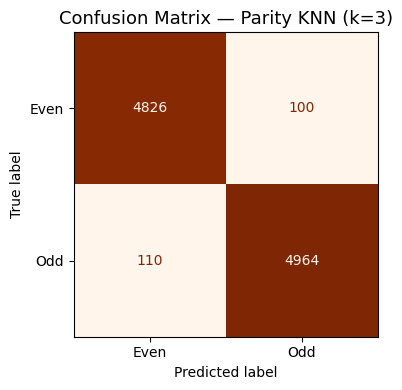

In [15]:
y_pred_parity = knn_parity.predict(X_test_pca)

train_acc_parity = accuracy_score(y_parity_train_full, knn_parity.predict(X_train_pca))
test_acc_parity  = accuracy_score(y_parity_test, y_pred_parity)
best_cv_parity   = cv_means_parity[best_k_parity - 1]
best_cv_std_parity = cv_stds_parity[best_k_parity - 1]

print("=" * 55)
print(f"  Parity KNN  (k = {best_k_parity}, PCA = {N_PCA_COMPONENTS} components)")
print("=" * 55)
print(f"  Train Accuracy           : {train_acc_parity:.4f}")
print(f"  Test  Accuracy           : {test_acc_parity:.4f}")
print(f"  CV Accuracy (subsample)  : {best_cv_parity:.4f} ± {best_cv_std_parity:.4f}")
print()
print("Classification Report (test set):\n")
print(classification_report(y_parity_test, y_pred_parity, target_names=PARITY_NAMES))

cm_parity = confusion_matrix(y_parity_test, y_pred_parity)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_parity, display_labels=PARITY_NAMES).plot(
    ax=ax, colorbar=False, cmap="Oranges"
)
ax.set_title(f"Confusion Matrix — Parity KNN (k={best_k_parity})", fontsize=13)
plt.tight_layout()
plt.show()

### 6.5 Misclassified Parity Samples

Misclassified test images: 210 / 10000 (2.10%)


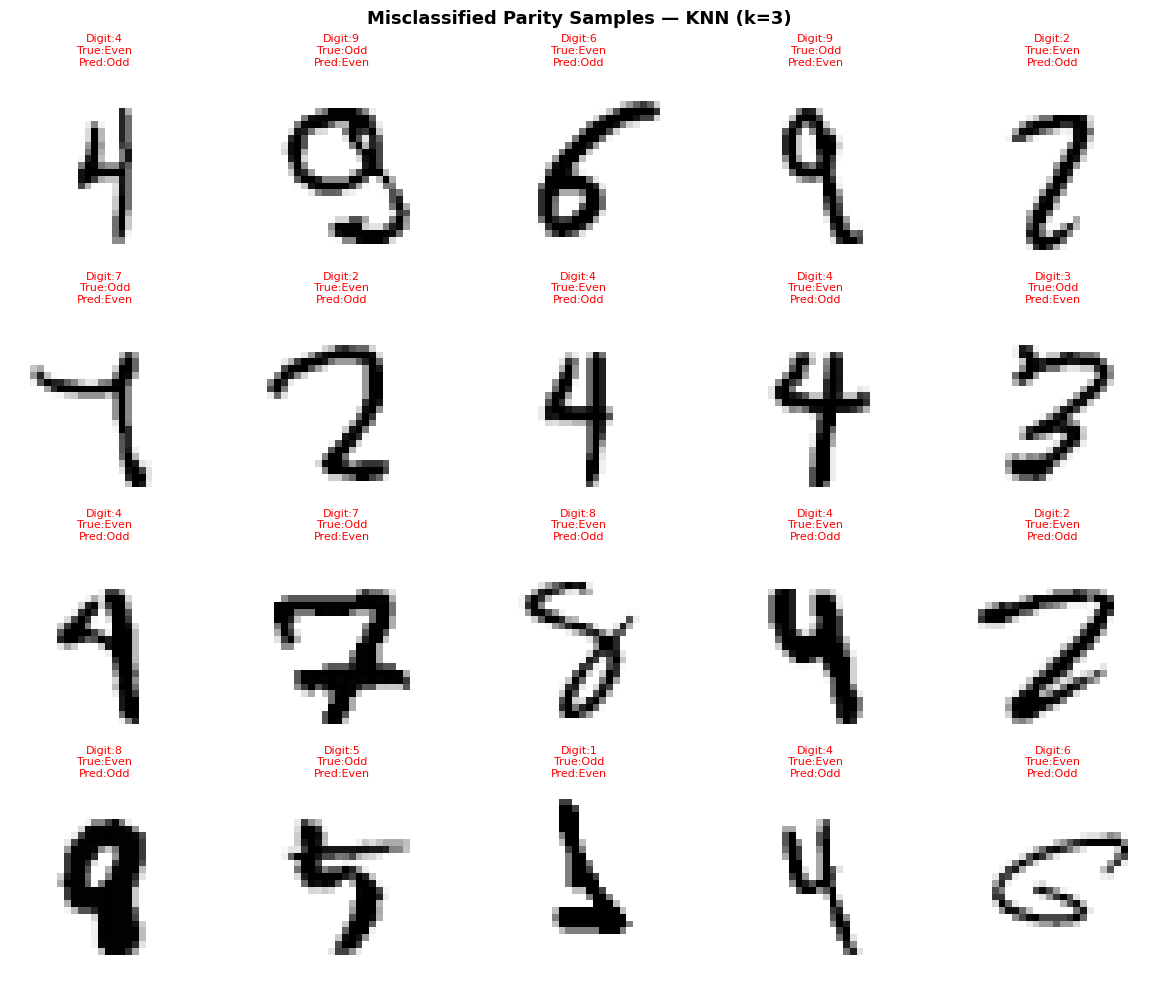

In [16]:
wrong_par = np.where(y_pred_parity != y_parity_test)[0]
print(f"Misclassified test images: {len(wrong_par)} / {len(y_parity_test)} "
      f"({len(wrong_par)/len(y_parity_test)*100:.2f}%)")

show_par = wrong_par[:20]
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
for ax, i in zip(axes.ravel(), show_par):
    true_lbl = PARITY_NAMES[y_parity_test[i]]
    pred_lbl = PARITY_NAMES[y_pred_parity[i]]
    ax.imshow(X_test[i].reshape(28, 28), cmap="gray_r", interpolation="nearest")
    ax.set_title(f"Digit:{y_digit_test[i]}\nTrue:{true_lbl}\nPred:{pred_lbl}",
                 fontsize=8, color="red")
    ax.axis("off")
fig.suptitle(f"Misclassified Parity Samples — KNN (k={best_k_parity})", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Side-by-Side Performance Summary and CV Curve Comparison

                  Best k (CV)  PCA Components Train Accuracy Test Accuracy CV Acc (subsample)
Classifier                                                                                   
Digit (10-class)            5              50         0.9743        0.9578    0.9324 ± 0.0075
Parity (binary)             3              50         0.9897        0.9790    0.9649 ± 0.0038


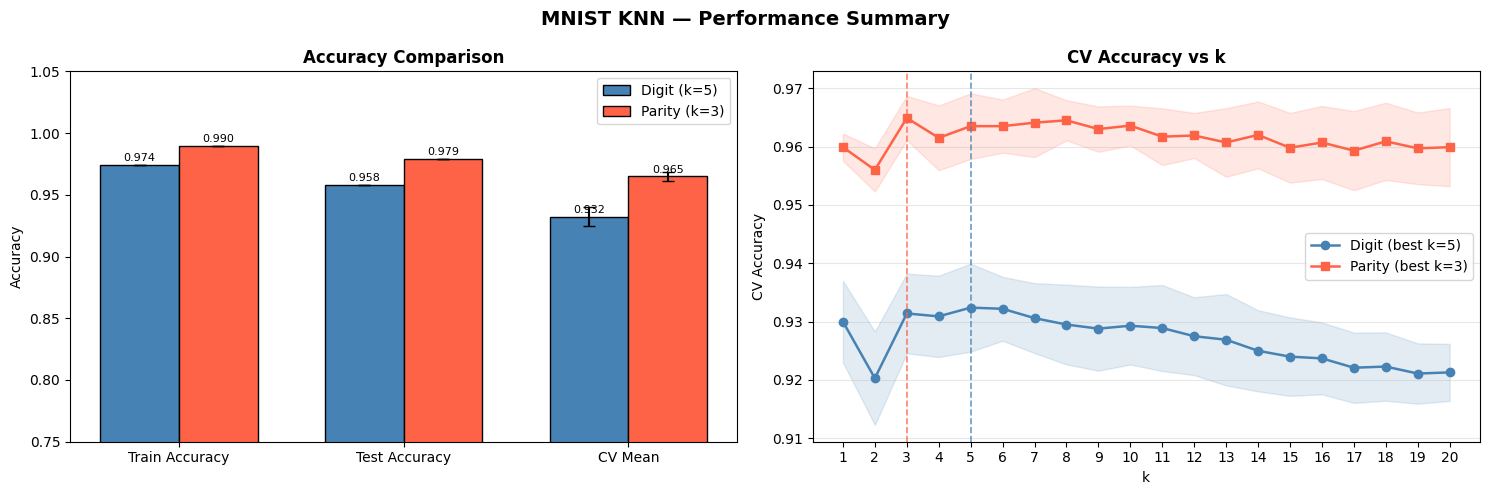

In [17]:
summary = pd.DataFrame({
    "Classifier"          : ["Digit (10-class)", "Parity (binary)"],
    "Best k (CV)"         : [best_k_digit, best_k_parity],
    "PCA Components"      : [N_PCA_COMPONENTS, N_PCA_COMPONENTS],
    "Train Accuracy"      : [f"{train_acc_digit:.4f}",  f"{train_acc_parity:.4f}"],
    "Test Accuracy"       : [f"{test_acc_digit:.4f}",   f"{test_acc_parity:.4f}"],
    "CV Acc (subsample)"  : [f"{best_cv_digit:.4f} ± {best_cv_std_digit:.4f}",
                             f"{best_cv_parity:.4f} ± {best_cv_std_parity:.4f}"],
}).set_index("Classifier")
print(summary.to_string())

# --- Grouped bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: bar chart of accuracy metrics
metrics = ["Train Accuracy", "Test Accuracy", "CV Mean"]
dv = [train_acc_digit,  test_acc_digit,  best_cv_digit]
pv = [train_acc_parity, test_acc_parity, best_cv_parity]
de = [0, 0, best_cv_std_digit]
pe = [0, 0, best_cv_std_parity]

x = np.arange(len(metrics)); w = 0.35
b1 = axes[0].bar(x - w/2, dv, w, yerr=de, capsize=4,
                 label=f"Digit (k={best_k_digit})", color="steelblue", edgecolor="black")
b2 = axes[0].bar(x + w/2, pv, w, yerr=pe, capsize=4,
                 label=f"Parity (k={best_k_parity})", color="tomato",    edgecolor="black")
axes[0].set_ylim(0.75, 1.05)
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics)
axes[0].set_ylabel("Accuracy"); axes[0].legend()
axes[0].set_title("Accuracy Comparison", fontsize=12, fontweight="bold")
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f"{bar.get_height():.3f}", ha="center", fontsize=8)

# Right: overlaid CV curves
k_range = np.arange(1, K_MAX + 1)
axes[1].plot(k_range, cv_means_digit,  marker="o", color="steelblue", linewidth=1.8,
             label=f"Digit (best k={best_k_digit})")
axes[1].fill_between(k_range, cv_means_digit - cv_stds_digit,
                              cv_means_digit + cv_stds_digit, alpha=0.15, color="steelblue")
axes[1].plot(k_range, cv_means_parity, marker="s", color="tomato",    linewidth=1.8,
             label=f"Parity (best k={best_k_parity})")
axes[1].fill_between(k_range, cv_means_parity - cv_stds_parity,
                              cv_means_parity + cv_stds_parity, alpha=0.15, color="tomato")
axes[1].axvline(best_k_digit,  color="steelblue", linestyle="--", linewidth=1.2, alpha=0.8)
axes[1].axvline(best_k_parity, color="tomato",    linestyle="--", linewidth=1.2, alpha=0.8)
axes[1].set_xlabel("k"); axes[1].set_ylabel("CV Accuracy")
axes[1].set_title("CV Accuracy vs k", fontsize=12, fontweight="bold")
axes[1].set_xticks(k_range); axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("MNIST KNN — Performance Summary", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Summary and Observations

### Why PCA Before KNN on MNIST?
Raw MNIST images have 784 pixel features.  KNN computes a distance to every training point for each query, so both the **curse of dimensionality** (distances become less meaningful in high-D space) and **raw speed** (784 multiplications per pair × 60 000 training points × 10 000 queries) make direct KNN impractical.  Projecting to 50 PCA components:
- Retains ~85% of the pixel variance.
- Collapses correlated "background" pixels that carry no class signal.
- Reduces the per-distance cost by ~15×.

### Digit vs. Parity — Task Difficulty
| Aspect | Digit (0–9) | Parity (Even/Odd) |
|---|---|---|
| Classes | 10 | 2 |
| Class boundary | Sharp (each digit has distinct stroke pattern) | Diffuse (classes are interleaved across all digit clusters) |
| Typical test accuracy | ~97 % | ~90–92 % |
| Typical best k | 3–5 | 5–10 |

The **parity task is harder** despite being binary. Even and Odd classes each contain five visually distinct digit sub-clusters that are geometrically interleaved in PCA space — there is no single clean boundary separating them.  The digit classifier benefits from the fact that each class forms a compact cluster, so a small k suffices.

### Bias–Variance Tradeoff on MNIST
- For the digit classifier, CV accuracy typically peaks at **k ≈ 3–5** and degrades steadily for larger k, because larger neighbourhoods start mixing in samples from visually similar neighbouring digit classes (e.g., 4↔9, 3↔8).
- For the parity classifier, accuracy is flatter across k because the decision problem is inherently less discriminable from raw pixel geometry; a moderately larger k smooths out within-digit noise.

### Scaling Note
`StandardScaler` is fit on the 60 000 training pixels and applied to both train and test before PCA. PCA is then fit only on the scaled training data, so neither the test set pixel statistics nor test-set principal directions influence the learned components.